# Banco de Dados II — Análise de mercado do Polymarket

**Trainee:** Pedro Henrique Ferrari

## Mercado escolhido

**Pergunta:** Will the Sacramento Kings make the NBA Playoffs?

**Market ID:** 521213

O mercado analisava se o Sacramento Kings conseguiria uma vaga nos playoffs da NBA.

## Pergunta de pesquisa

Como o volume e o preço médio mudaram ao longo do período e em quais registros ocorreram movimentos fora do padrão recente?

## Hipótese inicial

A expectativa era encontrar registros em que o volume ou a variação do preço ficassem bem acima do padrão recente. Depois, as mesmas regras foram testadas em mercados semelhantes para verificar se também funcionavam fora do caso do Sacramento Kings.

## 1. Exploração inicial do mercado

A primeira consulta foi utilizada para localizar o mercado e obter informações como identificador, volume total, data de criação e data de encerramento.

```sql
SELECT
  market_id,
  question,
  event_title,
  volume,
  created_at,
  end_date,
  closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) = LOWER(
  'Will the Sacramento Kings make the NBA Playoffs?'
)
ORDER BY volume DESC;
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_mercado = pd.read_csv("dados/01_mercado_escolhido.csv")

df_mercado

,market_id,question,event_title,volume,created_at,end_date,closed
0,521213,Will the Sacramento Kings make the NBA Playoffs?,Which teams will make the NBA Playoffs?,41161.060204,2025-01-31 19:08:14.000000 UTC,2025-04-19 12:00:00.000000 UTC,1


## 2. Histórico diário do mercado

A consulta recupera as duas medidas utilizadas na análise: volume diário e preço médio.

```sql
SELECT
  market_id,
  trade_date,
  daily_usd_volume,
  avg_trade_price
FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
WHERE market_id = '521213'
  AND trade_date BETWEEN DATE '2025-01-31'
                     AND DATE '2025-04-19'
ORDER BY trade_date;
```

In [2]:
df_diario = pd.read_csv(
    "dados/02_historico_diario.csv",
    parse_dates=["trade_date"]
)

df_diario.head()

,market_id,trade_date,daily_usd_volume,avg_trade_price
0,521213,2025-02-01,112.00,0.3200
1,521213,2025-02-02,1.71,0.3000
2,521213,2025-02-03,179.79,0.3925
3,521213,2025-02-04,73.02,0.3800
4,521213,2025-02-05,55.71,0.6100


In [3]:
print(f"Quantidade de dias com negociações: {len(df_diario)}")
print(f"Data inicial: {df_diario['trade_date'].min()}")
print(f"Data final: {df_diario['trade_date'].max()}")



Quantidade de dias com negociações: 53
Data inicial: 2025-02-01 00:00:00
Data final: 2025-04-17 00:00:00


## 3. Aplicação em mercados semelhantes

Para testar se a lógica não dependia apenas do Sacramento Kings, os mesmos alertas foram aplicados a outros quatro mercados da mesma temporada: Boston Celtics, Los Angeles Lakers, Phoenix Suns e Milwaukee Bucks.

Os IDs definem apenas a amostra utilizada no teste. Os cálculos e os limites dos alertas foram mantidos iguais para todos os mercados.

Para reduzir o volume de dados processados, foi utilizada a tabela agregada `daily_market_stats` em vez da tabela transacional de negociações. As consultas também foram limitadas aos mercados e ao período analisado, selecionando somente as colunas necessárias.

```sql
-- Histórico dos cinco mercados selecionados

WITH mercados AS (
  SELECT
    CAST(market_id AS STRING) AS market_id,
    question
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  WHERE closed = 1
    AND CAST(market_id AS STRING) IN (
      '521213', -- Sacramento Kings
      '521189', -- Boston Celtics
      '521201', -- Los Angeles Lakers
      '521211', -- Phoenix Suns
      '521204'  -- Milwaukee Bucks
    )
)

SELECT
  m.market_id,
  m.question,
  d.trade_date,
  d.daily_usd_volume,
  d.avg_trade_price
FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats` AS d
INNER JOIN mercados AS m
  ON d.market_id = m.market_id
WHERE d.trade_date BETWEEN DATE '2025-01-31'
                       AND DATE '2025-04-19'
ORDER BY
  m.question,
  d.trade_date;
```

In [4]:
df_metricas = pd.read_csv(
    "dados/04_metricas_mercados_nba.csv",
    parse_dates=["trade_date"]
)

df_metricas.head()

,market_id,question,trade_date,daily_usd_volume,avg_trade_price
0,521189,Will the Boston Celtics make the NBA Playoffs?,2025-02-01,0.03,0.002500
1,521189,Will the Boston Celtics make the NBA Playoffs?,2025-02-02,0.03,0.003000
2,521189,Will the Boston Celtics make the NBA Playoffs?,2025-02-03,5.98,0.167667
3,521189,Will the Boston Celtics make the NBA Playoffs?,2025-02-05,7.28,0.127000
4,521189,Will the Boston Celtics make the NBA Playoffs?,2025-02-06,4.92,0.982000


## 4. Alerta 1 — volume acima da média recente

O primeiro alerta compara o volume atual com a média de até sete registros anteriores de cada mercado.

O alerta exige pelo menos três observações anteriores e dispara quando o volume atual é pelo menos 2,5 vezes a média recente.
```sql
-- Alerta 1: volume diário anormal

WITH mercados AS (
  SELECT
    CAST(market_id AS STRING) AS market_id,
    question
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  WHERE closed = 1
    AND CAST(market_id AS STRING) IN (
      '521213',
      '521189',
      '521201',
      '521211',
      '521204'
    )
),

historico AS (
  SELECT
    m.market_id,
    m.question,
    d.trade_date,
    d.daily_usd_volume
  FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats` AS d
  INNER JOIN mercados AS m
    ON d.market_id = m.market_id
  WHERE d.trade_date BETWEEN DATE '2025-01-31'
                         AND DATE '2025-04-19'
),

medias AS (
  SELECT
    market_id,
    question,
    trade_date,
    daily_usd_volume,

    COUNT(daily_usd_volume) OVER (
      PARTITION BY market_id
      ORDER BY trade_date
      ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS observacoes_anteriores,

    AVG(daily_usd_volume) OVER (
      PARTITION BY market_id
      ORDER BY trade_date
      ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS media_volume_anterior

  FROM historico
)

SELECT
  market_id,
  question,
  trade_date,
  daily_usd_volume,
  media_volume_anterior
FROM medias
WHERE observacoes_anteriores >= 3
  AND media_volume_anterior > 0
  AND daily_usd_volume >= 2.5 * media_volume_anterior
ORDER BY
  trade_date,
  daily_usd_volume DESC;
```

In [5]:
df_alerta_volume = pd.read_csv(
    "dados/05_alerta_volume_nba.csv",
    parse_dates=["trade_date"]
)

print(f"Quantidade total de alertas: {len(df_alerta_volume)}")
print(
    f"Quantidade de mercados com alertas: "
    f"{df_alerta_volume['market_id'].nunique()}"
)

df_alerta_volume.head()

Quantidade total de alertas: 44
Quantidade de mercados com alertas: 5


,market_id,question,trade_date,daily_usd_volume,media_volume_anterior
0,521201,Will the Los Angeles Lakers make the NBA Playo...,2025-02-04,414.22,45.863333
1,521211,Will the Phoenix Suns make the NBA Playoffs?,2025-02-05,203.18,59.703333
2,521189,Will the Boston Celtics make the NBA Playoffs?,2025-02-05,7.28,2.013333
3,521204,Will the Milwaukee Bucks make the NBA Playoffs?,2025-02-07,78.97,30.523333
4,521201,Will the Los Angeles Lakers make the NBA Playo...,2025-02-08,1750.09,133.402857


## 5. Alerta 2 — mudança brusca no preço médio

O segundo alerta compara o preço médio atual com o preço do registro anterior do mesmo mercado.

O alerta dispara quando a diferença absoluta entre os dois preços é maior ou igual a 0,10.
```sql
-- Alerta 2: variação brusca do preço médio

WITH mercados AS (
  SELECT
    CAST(market_id AS STRING) AS market_id,
    question
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  WHERE closed = 1
    AND CAST(market_id AS STRING) IN (
      '521213',
      '521189',
      '521201',
      '521211',
      '521204'
    )
),

historico AS (
  SELECT
    m.market_id,
    m.question,
    d.trade_date,
    d.avg_trade_price
  FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats` AS d
  INNER JOIN mercados AS m
    ON d.market_id = m.market_id
  WHERE d.trade_date BETWEEN DATE '2025-01-31'
                         AND DATE '2025-04-19'
),

precos AS (
  SELECT
    market_id,
    question,
    trade_date,
    avg_trade_price,

    LAG(avg_trade_price) OVER (
      PARTITION BY market_id
      ORDER BY trade_date
    ) AS preco_anterior

  FROM historico
),

variacoes AS (
  SELECT
    market_id,
    question,
    trade_date,
    avg_trade_price,
    preco_anterior,

    avg_trade_price - preco_anterior
      AS variacao_preco,

    ABS(avg_trade_price - preco_anterior)
      AS variacao_absoluta_preco

  FROM precos
)

SELECT
  market_id,
  question,
  trade_date,
  avg_trade_price,
  preco_anterior,
  variacao_preco,
  variacao_absoluta_preco
FROM variacoes
WHERE preco_anterior IS NOT NULL
  AND variacao_absoluta_preco >= 0.10
ORDER BY
  trade_date,
  variacao_absoluta_preco DESC;
```

In [6]:
df_alerta_preco = pd.read_csv(
    "dados/06_alerta_preco_nba.csv",
    parse_dates=["trade_date"]
)

print(f"Quantidade total de alertas: {len(df_alerta_preco)}")

print(
    f"Quantidade de mercados com alertas: "
    f"{df_alerta_preco['market_id'].nunique()}"
)

df_alerta_preco.head()

Quantidade total de alertas: 133
Quantidade de mercados com alertas: 5


,market_id,question,trade_date,avg_trade_price,preco_anterior,variacao_preco,variacao_absoluta_preco
0,521204,Will the Milwaukee Bucks make the NBA Playoffs?,2025-02-01,0.050000,0.910000,-0.860000,0.860000
1,521201,Will the Los Angeles Lakers make the NBA Playo...,2025-02-01,0.540000,0.410000,0.130000,0.130000
2,521189,Will the Boston Celtics make the NBA Playoffs?,2025-02-03,0.167667,0.003000,0.164667,0.164667
3,521201,Will the Los Angeles Lakers make the NBA Playo...,2025-02-04,0.753333,0.442857,0.310476,0.310476
4,521201,Will the Los Angeles Lakers make the NBA Playo...,2025-02-05,0.383333,0.753333,-0.370000,0.370000


## 6. Visualização do Alerta 1 — volume acima da média recente

O gráfico abaixo apresenta o volume diário do mercado do Sacramento Kings. Os pontos destacados representam os dias em que o alerta de volume anormal foi disparado.

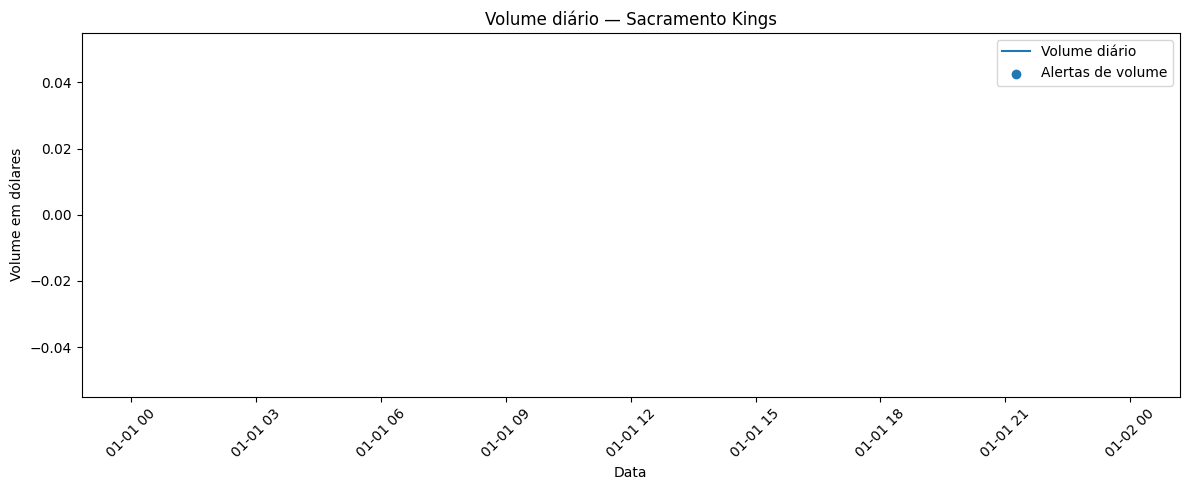

In [7]:
ID_SACRAMENTO = "521213"

sacramento = (
    df_metricas[
        df_metricas["market_id"] == ID_SACRAMENTO
    ]
    .sort_values("trade_date")
)

alertas_sacramento_volume = df_alerta_volume[
    df_alerta_volume["market_id"] == ID_SACRAMENTO
]

plt.figure(figsize=(12, 5))

plt.plot(
    sacramento["trade_date"],
    sacramento["daily_usd_volume"],
    label="Volume diário"
)

plt.scatter(
    alertas_sacramento_volume["trade_date"],
    alertas_sacramento_volume["daily_usd_volume"],
    label="Alertas de volume",
    zorder=3
)

plt.title("Volume diário — Sacramento Kings")
plt.xlabel("Data")
plt.ylabel("Volume em dólares")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
resumo_volume = (
    df_alerta_volume
    .groupby(
        ["market_id", "question"],
        as_index=False
    )
    .agg(
        quantidade_alertas=("trade_date", "count"),
    )
    .sort_values(
        "quantidade_alertas",
        ascending=False
    )
)

resumo_volume

,market_id,question,quantidade_alertas
0,521189,Will the Boston Celtics make the NBA Playoffs?,13
4,521213,Will the Sacramento Kings make the NBA Playoffs?,11
1,521201,Will the Los Angeles Lakers make the NBA Playo...,8
3,521211,Will the Phoenix Suns make the NBA Playoffs?,7
2,521204,Will the Milwaukee Bucks make the NBA Playoffs?,5


### Métrica de assertividade do Alerta 1

Um disparo foi considerado confirmado quando, no próximo registro observado, o volume negociado continuou acima da média móvel calculada com até sete registros anteriores no momento do alerta.

Essa métrica avalia se o movimento de volume teve continuidade. Ela não representa rentabilidade nem demonstra causalidade.

In [9]:
metricas_ordenadas = df_metricas.sort_values(
    ["market_id", "trade_date"]
).copy()

metricas_ordenadas["volume_dia_seguinte"] = (
    metricas_ordenadas
    .groupby("market_id")["daily_usd_volume"]
    .shift(-1)
)

avaliacao_volume = df_alerta_volume.merge(
    metricas_ordenadas[
        [
            "market_id",
            "trade_date",
            "volume_dia_seguinte"
        ]
    ],
    on=["market_id", "trade_date"],
    how="left"
)

avaliacao_volume["alerta_confirmado"] = (
    avaliacao_volume["volume_dia_seguinte"]
    > avaliacao_volume["media_volume_anterior"]
)


In [10]:
avaliacao_volume_valida = avaliacao_volume.dropna(
    subset=["volume_dia_seguinte"]
)

total_alertas_volume = len(avaliacao_volume_valida)

confirmados_volume = (
    avaliacao_volume_valida["alerta_confirmado"].sum()
)

assertividade_volume = (
    confirmados_volume / total_alertas_volume
    if total_alertas_volume > 0
    else 0
)

print(f"Alertas avaliados: {total_alertas_volume}")
print(f"Alertas confirmados: {confirmados_volume}")
print(f"Assertividade do Alerta 1: {assertividade_volume:.2%}")

Alertas avaliados: 41
Alertas confirmados: 21
Assertividade do Alerta 1: 51.22%


## 7. Visualização do Alerta 2 — variação brusca do preço médio

O gráfico apresenta o preço médio negociado no mercado do Sacramento Kings. Os pontos destacados mostram os dias em que o alerta identificou uma variação brusca.

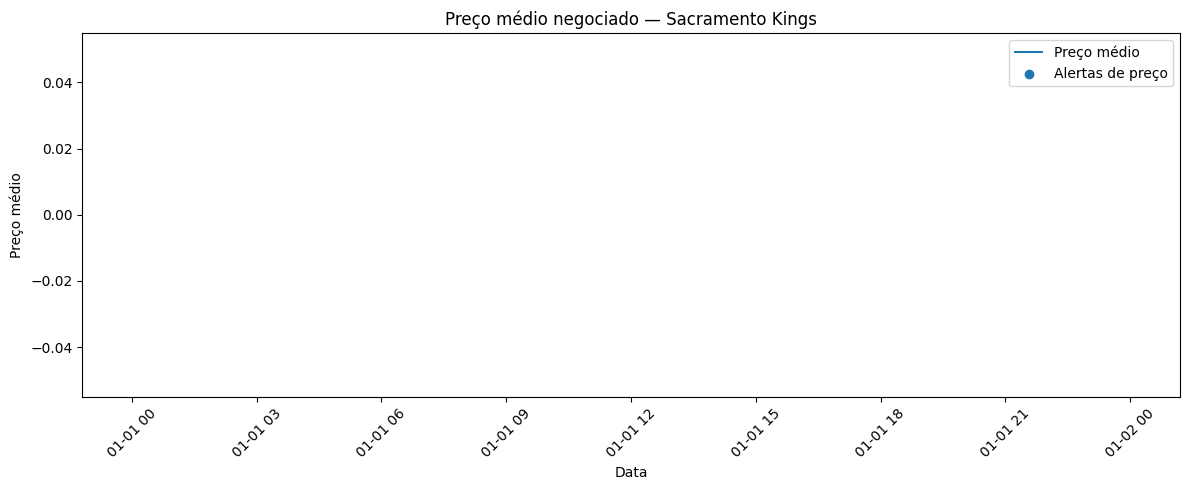

In [11]:
alertas_sacramento_preco = df_alerta_preco[
    df_alerta_preco["market_id"] == ID_SACRAMENTO
]

plt.figure(figsize=(12, 5))

plt.plot(
    sacramento["trade_date"],
    sacramento["avg_trade_price"],
    label="Preço médio"
)

plt.scatter(
    alertas_sacramento_preco["trade_date"],
    alertas_sacramento_preco["avg_trade_price"],
    label="Alertas de preço",
    zorder=3
)

plt.title("Preço médio negociado — Sacramento Kings")
plt.xlabel("Data")
plt.ylabel("Preço médio")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
resumo_preco = (
    df_alerta_preco
    .groupby(
        ["market_id", "question"],
        as_index=False
    )
    .agg(
        quantidade_alertas=("trade_date", "count"),
    )
    .sort_values(
        "quantidade_alertas",
        ascending=False
    )
)

resumo_preco

,market_id,question,quantidade_alertas
1,521201,Will the Los Angeles Lakers make the NBA Playo...,38
3,521211,Will the Phoenix Suns make the NBA Playoffs?,35
4,521213,Will the Sacramento Kings make the NBA Playoffs?,28
0,521189,Will the Boston Celtics make the NBA Playoffs?,18
2,521204,Will the Milwaukee Bucks make the NBA Playoffs?,14


### Métrica de assertividade do Alerta 2

O alerta foi considerado confirmado quando o preço continuou na mesma direção no registro seguinte, com uma nova variação de pelo menos 0,03.

Essa métrica avalia apenas a continuidade do movimento e não representa retorno financeiro.

In [13]:
metricas_ordenadas["preco_dia_seguinte"] = (
    metricas_ordenadas
    .groupby("market_id")["avg_trade_price"]
    .shift(-1)
)

avaliacao_preco = df_alerta_preco.merge(
    metricas_ordenadas[
        [
            "market_id",
            "trade_date",
            "preco_dia_seguinte"
        ]
    ],
    on=["market_id", "trade_date"],
    how="left"
)

avaliacao_preco["movimento_seguinte"] = (
    avaliacao_preco["preco_dia_seguinte"]
    - avaliacao_preco["avg_trade_price"]
)

avaliacao_preco["mesma_direcao"] = (
    np.sign(avaliacao_preco["movimento_seguinte"])
    == np.sign(avaliacao_preco["variacao_preco"])
)

avaliacao_preco["alerta_confirmado"] = (
    avaliacao_preco["mesma_direcao"]
    & (
        avaliacao_preco["movimento_seguinte"].abs()
        >= 0.03
    )
)


In [14]:
avaliacao_preco_valida = avaliacao_preco.dropna(
    subset=["preco_dia_seguinte"]
)

total_alertas_preco = len(avaliacao_preco_valida)

confirmados_preco = (
    avaliacao_preco_valida["alerta_confirmado"].sum()
)

assertividade_preco = (
    confirmados_preco / total_alertas_preco
    if total_alertas_preco > 0
    else 0
)

print(f"Alertas avaliados: {total_alertas_preco}")
print(f"Alertas confirmados: {confirmados_preco}")
print(f"Assertividade do Alerta 2: {assertividade_preco:.2%}")

Alertas avaliados: 129
Alertas confirmados: 30
Assertividade do Alerta 2: 23.26%


## 8. Resultados

O alerta de volume gerou 44 disparos. Dos 41 que tinham um registro posterior, 21 foram confirmados, resultando em uma assertividade de 51,22%. A regra disparou nos cinco mercados analisados.

O alerta de preço gerou 133 disparos. Dos 129 que tinham um registro posterior, 30 foram confirmados, resultando em uma assertividade de 23,26%.

O alerta de preço disparou mais vezes, mas apresentou menor proporção de confirmações. Isso indica que um limite mais alto poderia reduzir alertas que não tiveram continuidade no registro seguinte.

## 9. Conclusão

As duas regras puderam ser aplicadas aos cinco mercados sem mudança nos parâmetros, portanto não ficaram restritas ao Sacramento Kings.

O alerta de volume apresentou maior proporção de confirmações. O alerta de preço disparou mais vezes, mas teve menor assertividade.

Em uma análise futura, eu testaria um limite mais alto no alerta de preço para tentar reduzir disparos sem continuidade.

## 10. Limitações

Os dados são agregados por dia, então movimentos dentro do mesmo dia não aparecem separadamente. O preço médio também não foi tratado como a probabilidade exata do resultado “Yes”.

A janela utiliza até sete registros anteriores, que não correspondem necessariamente a sete dias seguidos. A assertividade mede apenas se o movimento continuou no registro seguinte e não representa retorno financeiro.

Como os mercados possuem níveis diferentes de atividade, a mesma regra pode gerar quantidades diferentes de alertas. Além disso, uma média recente muito baixa pode fazer com que um aumento pequeno em valor absoluto seja suficiente para disparar o alerta de volume.